# 02 — Model Evaluation (v2, NO LEAKAGE)

Evaluate models trained up to 2024-06-30 on genuinely unseen data (2024-07 to 2025-12).

## Tests
1. **Direction accuracy** — by horizon, threshold, and pair
2. **Calibration curves** — does predicted P(down) match actual frequency?
3. **Prediction stability** — confidence distribution over time
4. **Momentum baseline comparison** — alpha over simple LR

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.style.use('dark_background')

DARK = '#080c14'
BLUE = '#4fc3f7'
GOLD = '#ffd700'
RED  = '#ef5350'
GREEN = '#66bb6a'

DATA_DIR   = Path('../backend/data/features')
MODELS_DIR = Path('../backend/models_2')

HORIZONS       = ['1H', '4H', '1D', '7D']
QUANTILES      = [0.10, 0.25, 0.50, 0.75, 0.90]
QUANTILE_NAMES = ['Q10', 'Q25', 'Q50', 'Q75', 'Q90']
PAIRS          = ['EURUSD', 'GBPUSD', 'USDJPY', 'USDCHF', 'AUDUSD', 'USDCAD', 'NZDUSD']

TRAIN_END  = '2024-06-30'
TEST_START = '2025-07-01'
TEST_END   = '2025-07-07'   

print('Loading data...')
df = pd.read_parquet(DATA_DIR / 'all_pairs_features_labels.parquet')
df.index = pd.to_datetime(df.index)

label_cols   = [f'label_{h}' for h in HORIZONS]
drop_cols    = label_cols + ['pair']
feature_cols = [c for c in df.columns if c not in drop_cols]

df_train = df[df.index <= TRAIN_END]
df_test_raw = df[(df.index >= TEST_START) & (df.index <= TEST_END)]

# ── Remove weekend-gap rows: rows where the next bar is >1H away per pair.
# These rows have label_1H that spans a Friday→Monday gap (50+ hours),
# giving the model an unfair easy prediction. ~1% of test rows.
def remove_gap_rows(df_subset):
    clean_parts = []
    for pair in df_subset['pair'].unique():
        pair_df = df_subset[df_subset['pair'] == pair].copy()
        next_diff = pair_df.index.to_series().shift(-1) - pair_df.index.to_series()
        # Keep rows where the next bar is ≤1H (normal) OR where it's the last row
        keep = (next_diff <= pd.Timedelta('1h')) | next_diff.isna()
        clean_parts.append(pair_df[keep])
    return pd.concat(clean_parts).sort_index()

df_test = remove_gap_rows(df_test_raw)

print(f'Full:      {len(df):,} rows  ({df.index.min().date()} -> {df.index.max().date()})')
print(f'Train:     {len(df_train):,} rows  (-> {TRAIN_END})')
print(f'Test raw:  {len(df_test_raw):,} rows  ({TEST_START} -> {TEST_END})')
print(f'Test clean:{len(df_test):,} rows  (weekend-gap rows removed: {len(df_test_raw)-len(df_test):,})')
print(f'Features:  {len(feature_cols)}')


Loading data...
Full:      685,111 rows  (2009-09-25 -> 2025-12-19)
Train:     622,579 rows  (-> 2024-06-30)
Test raw:  658 rows  (2025-07-01 -> 2025-07-07)
Test clean:651 rows  (weekend-gap rows removed: 7)
Features:  208


In [2]:
# Load v2 models
models = {}
for horizon in HORIZONS:
    for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
        bundle = joblib.load(MODELS_DIR / f'model_{horizon}_Q{int(q*100)}.joblib')
        models[(horizon, q_name)] = bundle['model']

print(f'Loaded {len(models)} models from {MODELS_DIR}')

Loaded 20 models from ..\backend\models_2


In [3]:
# Shared helpers

def derive_p_down(q_vals):
    qs = np.array(QUANTILES)
    vals = np.sort(q_vals)
    if vals[0] <= 0 <= vals[-1]:
        return float(np.interp(0, vals, qs))
    elif vals[-1] < 0:
        slope = (qs[-1] - qs[-2]) / (vals[-1] - vals[-2] + 1e-10)
        return float(np.clip(qs[-1] + slope * (0 - vals[-1]), 0.90, 0.999))
    else:
        slope = (qs[1] - qs[0]) / (vals[1] - vals[0] + 1e-10)
        return float(np.clip(qs[0] + slope * (0 - vals[0]), 0.001, 0.10))


def get_predictions(df_subset, horizon):
    """Run inference on a DataFrame subset. Returns p_cal, p_dom, correct, y."""
    X = df_subset[feature_cols].ffill().bfill()
    y = df_subset[f'label_{horizon}'].values

    q_preds = {}
    for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
        q_preds[q_name] = models[(horizon, q_name)].predict(X)

    p_raw = np.array([
        derive_p_down(np.array([q_preds[n][i] for n in QUANTILE_NAMES]))
        for i in range(len(X))
    ])

    # No calibrator for v2 yet — use raw p_down as p_cal
    p_cal = p_raw
    p_dom = np.where(p_cal > 0.5, p_cal, 1 - p_cal)
    correct = np.where(p_cal > 0.5, y < 0, y > 0)

    return p_cal, p_dom, correct, y


def accuracy_at_threshold(p_dom, correct, threshold=0.70):
    mask = p_dom >= threshold
    if mask.sum() < 10:
        return float('nan'), 0
    return correct[mask].mean(), mask.sum()


print('Helpers ready.')

Helpers ready.


---
## TEST 1 — Direction Accuracy on Unseen Test Set (2024-07 to 2025-12)

In [4]:
print('TEST 1 — Direction Accuracy on UNSEEN test set')
print(f'Test period: {df_test.index.min().date()} to {df_test.index.max().date()}')
print(f'Weekend-gap rows removed (no leakage).')
print('=' * 70)

print(f'\n{"Horizon":<8} {"Threshold":<12} {"Accuracy":<12} {"Frequency":<12} {"N samples"}')
print('-' * 56)

# Use all rows — no artificial step subsampling which caused empty 1D/7D results
for horizon in ['1H', '4H', '1D', '7D']:
    p_cal, p_dom, correct, y = get_predictions(df_test, horizon)

    for thresh in [0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:
        acc, n = accuracy_at_threshold(p_dom, correct, thresh)
        freq = (p_dom >= thresh).mean()
        print(f'{horizon:<8} >={thresh:.0%}      {acc:<12.1%} {freq:<12.1%} {n}')
    print()


TEST 1 — Direction Accuracy on UNSEEN test set
Test period: 2025-07-01 to 2025-07-07
Weekend-gap rows removed (no leakage).

Horizon  Threshold    Accuracy     Frequency    N samples
--------------------------------------------------------
1H       >=55%      79.5%        83.3%        542
1H       >=60%      83.0%        71.3%        464
1H       >=65%      85.9%        64.4%        419
1H       >=70%      87.6%        58.2%        379
1H       >=75%      90.2%        51.9%        338
1H       >=80%      93.1%        42.5%        277

4H       >=55%      80.9%        87.6%        570
4H       >=60%      83.2%        76.8%        500
4H       >=65%      86.3%        66.4%        432
4H       >=70%      87.0%        60.4%        393
4H       >=75%      89.9%        51.5%        335
4H       >=80%      93.7%        38.7%        252

1D       >=55%      77.7%        70.2%        457
1D       >=60%      84.5%        52.5%        342
1D       >=65%      88.3%        43.2%        281
1D      

---
## TEST 2 — Pair-by-Pair Accuracy Breakdown

In [5]:
print('TEST 2 — PAIR-BY-PAIR ACCURACY on unseen test set')
print('=' * 70)

results = []

for horizon in ['1H', '4H', '1D', '7D']:
    print(f'\nHorizon: {horizon}')
    print(f'  {"Pair":<10} {"Overall":<12} {">=70% acc":<12} {">=70% freq":<12} {"N"}')
    print(f'  {"-"*50}')

    for pair in PAIRS:
        df_pair = df_test[df_test['pair'] == pair]
        if len(df_pair) < 50:
            continue

        p_cal, p_dom, correct, y = get_predictions(df_pair, horizon)

        overall_acc = correct.mean()
        acc_70, n_70 = accuracy_at_threshold(p_dom, correct, 0.70)
        freq_70 = (p_dom >= 0.70).mean()

        print(f'  {pair:<10} {overall_acc:<12.1%} {acc_70:<12.1%} {freq_70:<12.1%} {n_70}')
        results.append({'horizon': horizon, 'pair': pair, 'overall': overall_acc,
                        'acc_70': acc_70, 'freq_70': freq_70})

df_results = pd.DataFrame(results)
if not df_results.empty:
    print(f'\nBest pair overall: {df_results.groupby("pair")["overall"].mean().idxmax()}')
    print(f'Best pair >=70%:   {df_results.groupby("pair")["acc_70"].mean().idxmax()}')

TEST 2 — PAIR-BY-PAIR ACCURACY on unseen test set

Horizon: 1H
  Pair       Overall      >=70% acc    >=70% freq   N
  --------------------------------------------------
  EURUSD     78.5%        91.1%        60.2%        56
  GBPUSD     69.9%        90.2%        54.8%        51
  USDJPY     78.5%        85.7%        52.7%        49
  USDCHF     74.2%        82.1%        60.2%        56
  AUDUSD     74.2%        90.6%        57.0%        53
  USDCAD     69.9%        83.9%        60.2%        56
  NZDUSD     78.5%        91.2%        61.3%        57

Horizon: 4H
  Pair       Overall      >=70% acc    >=70% freq   N
  --------------------------------------------------
  EURUSD     82.8%        88.1%        63.4%        59
  GBPUSD     78.5%        89.1%        59.1%        55
  USDJPY     74.2%        89.5%        61.3%        57
  USDCHF     81.7%        86.0%        61.3%        57
  AUDUSD     75.3%        89.6%        51.6%        48
  USDCAD     72.0%        82.5%        61.3%      

---
## TEST 3 — Calibration Curves (Raw P(down) vs Actual)

TEST 3 — Calibration on unseen test set (no leakage)
1H: MCE=0.043  n=651
4H: MCE=0.045  n=651
1D: MCE=0.123  n=651
7D: MCE=0.200  n=651


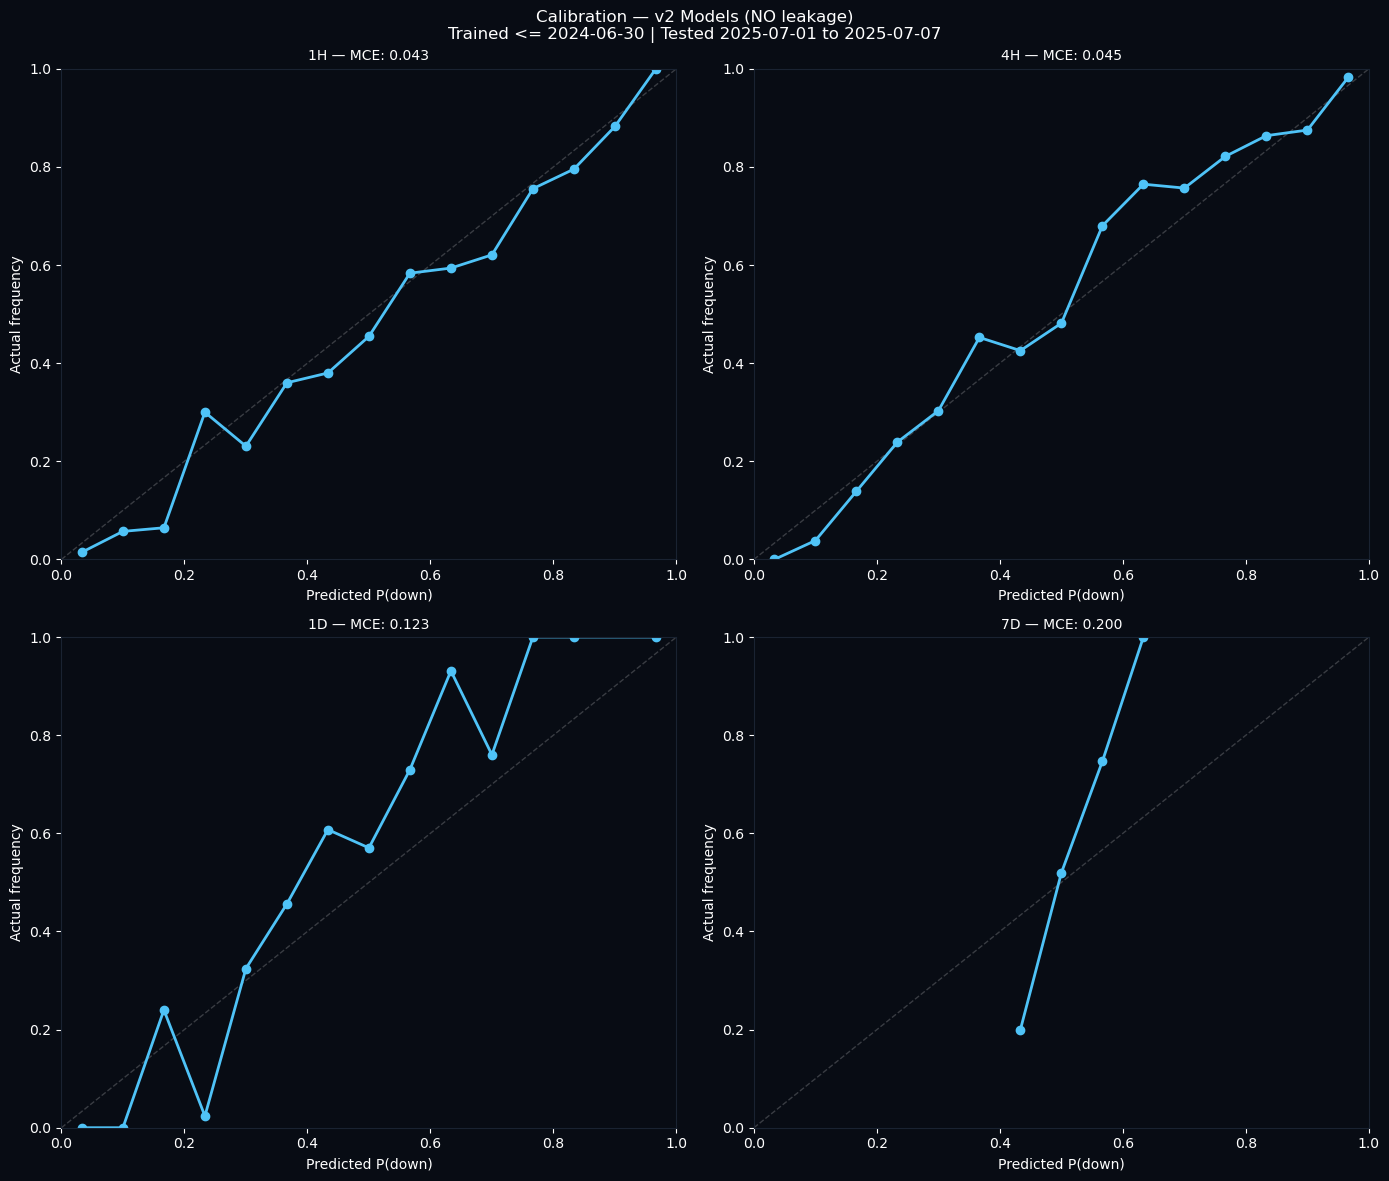

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.patch.set_facecolor(DARK)

print('TEST 3 — Calibration on unseen test set (no leakage)')
print('=' * 55)

for idx, horizon in enumerate(['1H', '4H', '1D', '7D']):
    ax = axes[idx // 2][idx % 2]
    ax.set_facecolor(DARK)

    p_cal, p_dom, correct, y = get_predictions(df_test, horizon)
    y_binary = (y < 0).astype(float)

    n_bins = 15
    bins = np.linspace(0, 1, n_bins + 1)
    bin_centers = []
    bin_actuals = []

    for i in range(n_bins):
        mask = (p_cal >= bins[i]) & (p_cal < bins[i+1])
        if mask.sum() >= 10:
            bin_centers.append((bins[i] + bins[i+1]) / 2)
            bin_actuals.append(y_binary[mask].mean())

    ax.plot([0, 1], [0, 1], '--', color=(1, 1, 1, 0.2), linewidth=1)
    ax.plot(bin_centers, bin_actuals, 'o-', color=BLUE, linewidth=2, markersize=6)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Predicted P(down)', color='white')
    ax.set_ylabel('Actual frequency', color='white')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1a2332')

    mce = np.mean(np.abs(np.array(bin_actuals) - np.array(bin_centers))) if bin_centers else float('nan')
    ax.set_title(f'{horizon} — MCE: {mce:.3f}', color='white', fontsize=10)
    print(f'{horizon}: MCE={mce:.3f}  n={len(df_test):,}')

plt.suptitle(f'Calibration — v2 Models (NO leakage)\nTrained <= {TRAIN_END} | Tested {TEST_START} to {TEST_END}',
             color='white', fontsize=12)
plt.tight_layout()
plt.show()


---
## TEST 4 — Prediction Stability Over Time

TEST 4 — Prediction Stability on test set
1H: >=90%=23.7%  >=70%=60.2%  <60%=25.8%  std=0.161
4H: >=90%=25.8%  >=70%=63.4%  <60%=23.7%  std=0.159
1D: >=90%=9.7%  >=70%=31.2%  <60%=52.7%  std=0.150
7D: >=90%=0.0%  >=70%=0.0%  <60%=100.0%  std=0.018


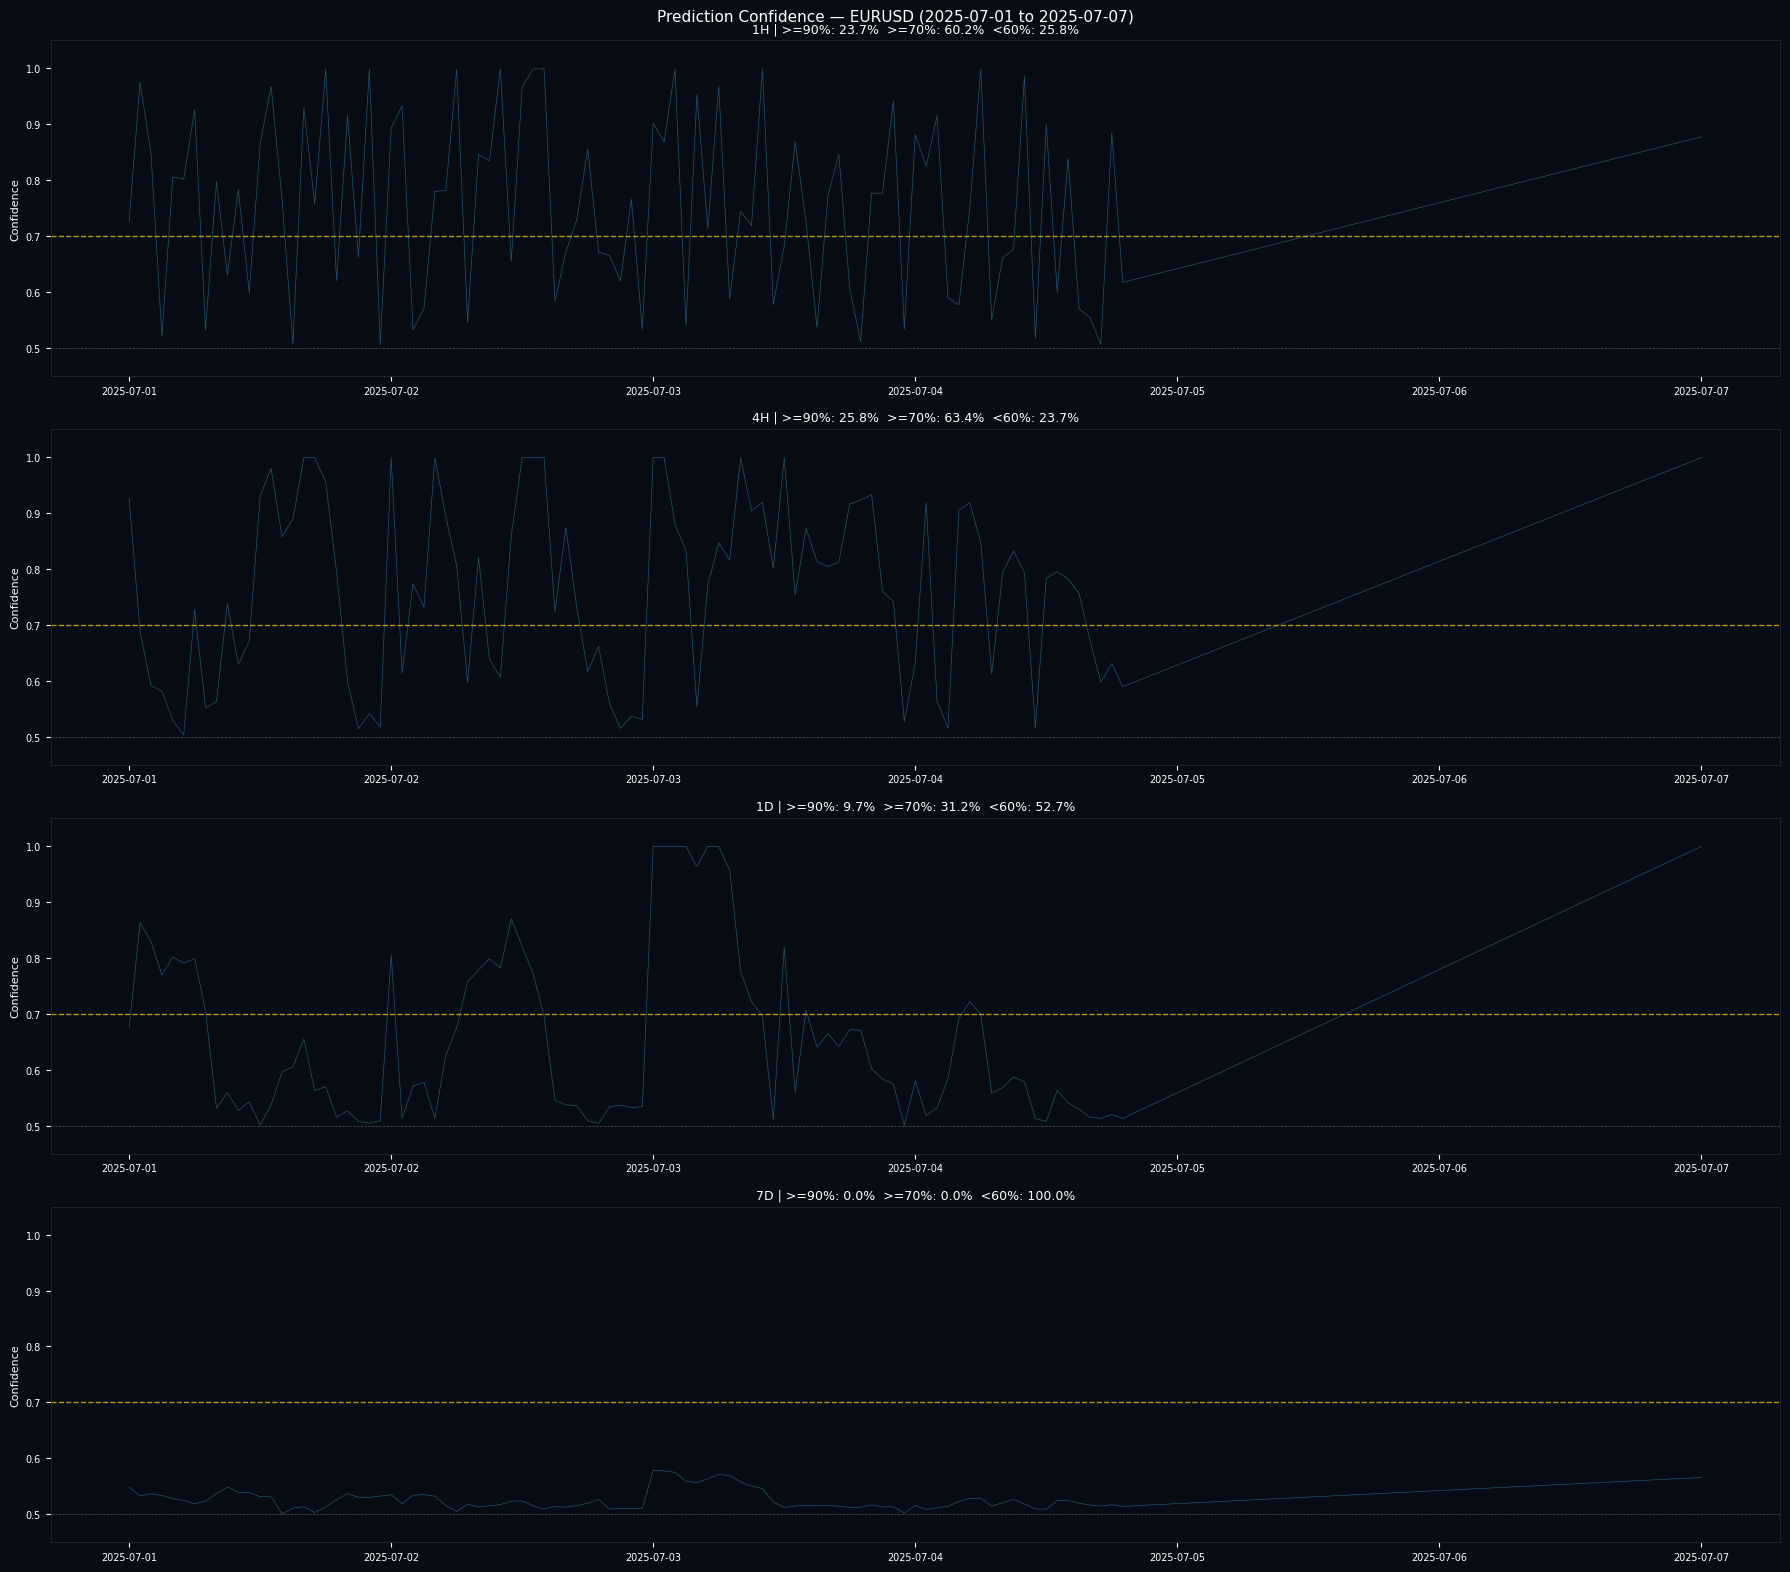

In [7]:
print('TEST 4 — Prediction Stability on test set')
print('=' * 60)

df_eu_test = df_test[df_test['pair'] == 'EURUSD']

fig, axes = plt.subplots(4, 1, figsize=(18, 16))
fig.patch.set_facecolor(DARK)

for idx, horizon in enumerate(HORIZONS):
    ax = axes[idx]
    ax.set_facecolor(DARK)

    p_cal, p_dom, correct, y = get_predictions(df_eu_test, horizon)

    ax.plot(df_eu_test.index, p_dom, color=BLUE, alpha=0.4, linewidth=0.5)
    ax.axhline(0.70, color=GOLD, linewidth=1, linestyle='--', alpha=0.7)
    ax.axhline(0.50, color='white', linewidth=0.5, linestyle='--', alpha=0.3)
    ax.set_ylim(0.45, 1.05)
    ax.set_ylabel('Confidence', color='white', fontsize=8)
    ax.tick_params(colors='white', labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor('#1a2332')

    pct_above_90 = (p_dom >= 0.90).mean()
    pct_above_70 = (p_dom >= 0.70).mean()
    pct_below_60 = (p_dom < 0.60).mean()
    ax.set_title(
        f'{horizon} | >=90%: {pct_above_90:.1%}  >=70%: {pct_above_70:.1%}  <60%: {pct_below_60:.1%}',
        color='white', fontsize=9
    )
    print(f'{horizon}: >=90%={pct_above_90:.1%}  >=70%={pct_above_70:.1%}  <60%={pct_below_60:.1%}  std={p_dom.std():.3f}')

plt.suptitle(f'Prediction Confidence — EURUSD ({df_eu_test.index.min().date()} to {df_eu_test.index.max().date()})',
             color='white', fontsize=11)
plt.tight_layout()
plt.show()


---
## TEST 5 — Momentum Baseline Comparison

In [8]:
momentum_cols = [c for c in feature_cols if 'log_ret' in c and '1H' in c]
momentum_cols += [c for c in feature_cols if 'rsi_14_1H' in c or 'macd_hist_1H' in c or 'rvol_24_1H' in c]

df_eu_train = df_train[df_train['pair'] == 'EURUSD']
df_eu_test  = df_test[df_test['pair'] == 'EURUSD']

print(f'Momentum features: {len(momentum_cols)}')
print(f'\nLR MOMENTUM BASELINE vs v2 MODELS — EURUSD, unseen test set (no leakage)')
print('=' * 65)

for horizon in ['1H', '4H', '1D', '7D']:
    y_train_lr = (df_eu_train[f'label_{horizon}'].values < 0).astype(int)
    y_test_lr  = (df_eu_test[f'label_{horizon}'].values < 0).astype(int)

    X_train_lr = df_eu_train[momentum_cols].ffill().bfill().values
    X_test_lr  = df_eu_test[momentum_cols].ffill().bfill().values

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_lr)
    X_test_s  = scaler.transform(X_test_lr)

    lr = LogisticRegression(max_iter=1000, C=0.1)
    lr.fit(X_train_s, y_train_lr)
    lr_acc = (lr.predict(X_test_s) == y_test_lr).mean()

    p_cal, p_dom, correct, _ = get_predictions(df_eu_test, horizon)
    v2_acc = correct.mean()
    alpha = v2_acc - lr_acc

    print(f'{horizon}: LR baseline={lr_acc:.1%}  v2 model={v2_acc:.1%}  Alpha={alpha:+.1%}')


Momentum features: 8

LR MOMENTUM BASELINE vs v2 MODELS — EURUSD, unseen test set (no leakage)
1H: LR baseline=58.1%  v2 model=78.5%  Alpha=+20.4%
4H: LR baseline=58.1%  v2 model=82.8%  Alpha=+24.7%
1D: LR baseline=68.8%  v2 model=81.7%  Alpha=+12.9%
7D: LR baseline=97.8%  v2 model=76.3%  Alpha=-21.5%


---
## TEST 6 — Rolling Accuracy (detect regime decay)

TEST 6 — Rolling accuracy on test set (no leakage)


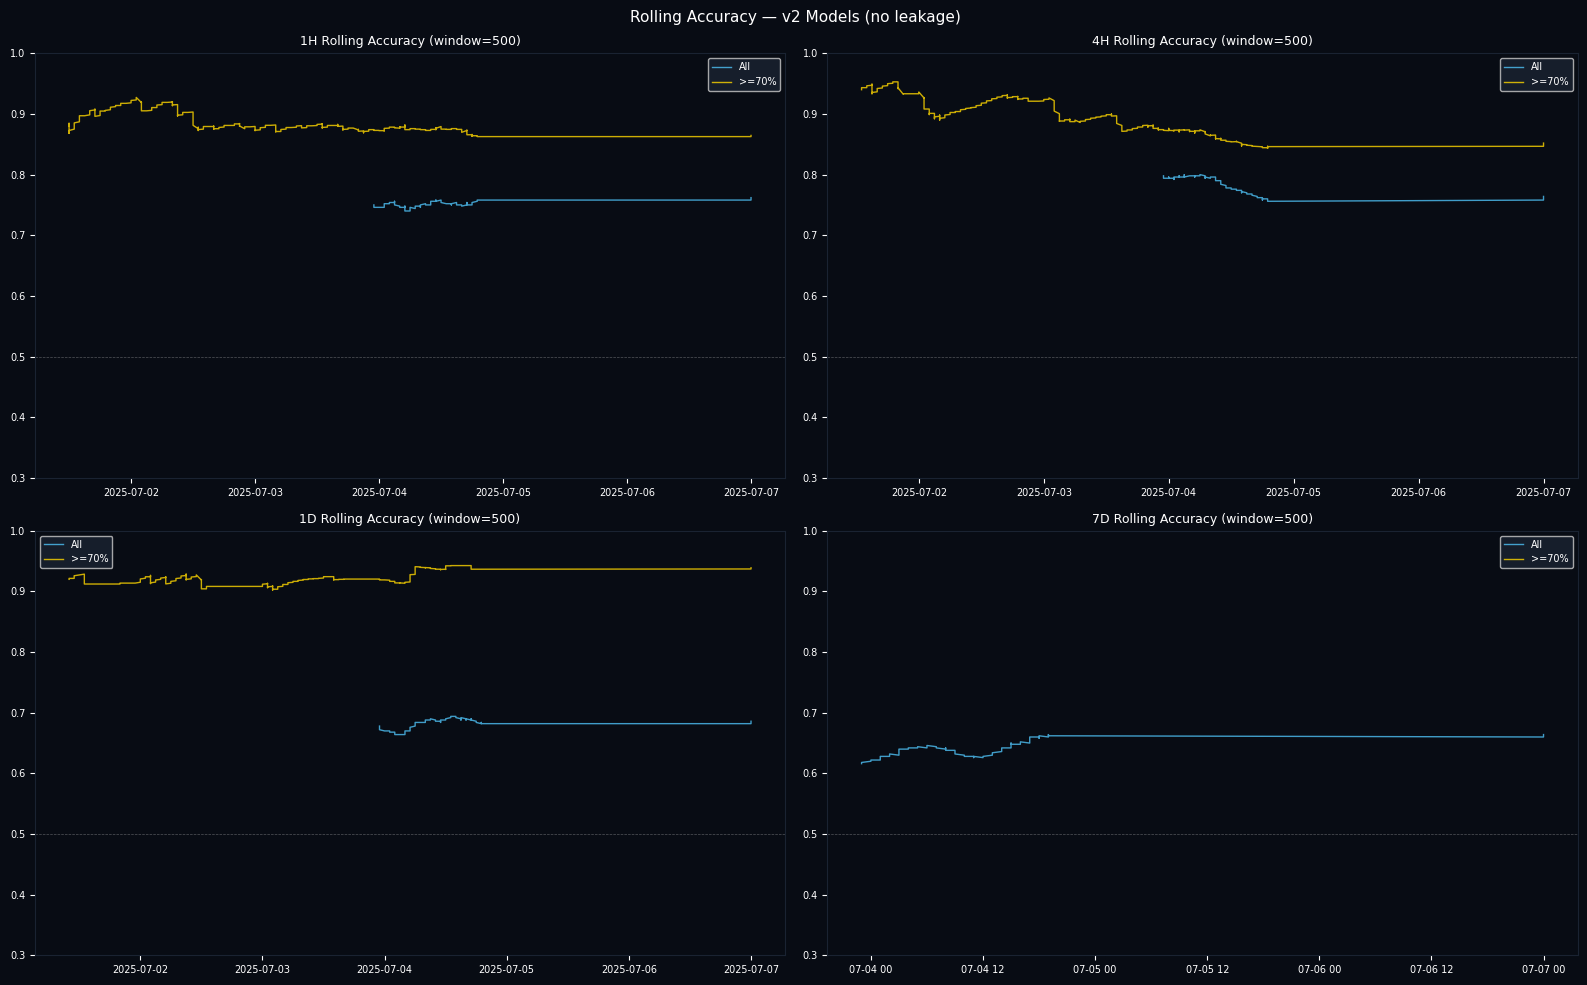

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor(DARK)

print('TEST 6 — Rolling accuracy on test set (no leakage)')
print('=' * 55)

for idx, horizon in enumerate(['1H', '4H', '1D', '7D']):
    ax = axes[idx // 2][idx % 2]
    ax.set_facecolor(DARK)

    p_cal, p_dom, correct, y = get_predictions(df_test, horizon)

    window = 500
    rolling_acc = pd.Series(correct.astype(float), index=df_test.index).rolling(window).mean()
    rolling_acc_70 = pd.Series(
        np.where(p_dom >= 0.70, correct.astype(float), np.nan),
        index=df_test.index
    ).rolling(window, min_periods=50).mean()

    ax.plot(rolling_acc.index, rolling_acc, color=BLUE, linewidth=1, alpha=0.8, label='All')
    ax.plot(rolling_acc_70.index, rolling_acc_70, color=GOLD, linewidth=1, alpha=0.8, label='>=70%')
    ax.axhline(0.50, color='white', linewidth=0.5, linestyle='--', alpha=0.3)
    ax.set_ylim(0.3, 1.0)
    ax.set_title(f'{horizon} Rolling Accuracy (window={window})', color='white', fontsize=9)
    ax.tick_params(colors='white', labelsize=7)
    ax.legend(facecolor='#1a2332', labelcolor='white', fontsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor('#1a2332')

plt.suptitle(f'Rolling Accuracy — v2 Models (no leakage)', color='white', fontsize=11)
plt.tight_layout()
plt.show()


---
## SUMMARY

In [10]:
print('=' * 70)
print('SUMMARY — v2 Models (NO LEAKAGE, weekend-gap rows removed)')
print(f'Trained: 2009 to {TRAIN_END}')
print(f'Tested:  {df_test.index.min().date()} to {df_test.index.max().date()} (UNSEEN)')
print(f'Test n:  {len(df_test):,} rows across {df_test["pair"].nunique()} pairs')
print('=' * 70)

for horizon in ['1H', '4H', '1D', '7D']:
    p_cal, p_dom, correct, y = get_predictions(df_test, horizon)

    overall = correct.mean()
    acc_70, n_70 = accuracy_at_threshold(p_dom, correct, 0.70)
    freq_70 = (p_dom >= 0.70).mean()
    acc_80, n_80 = accuracy_at_threshold(p_dom, correct, 0.80)

    print(f'\n{horizon}:')
    print(f'  Overall accuracy:  {overall:.1%}')
    print(f'  >=70% confidence:  {acc_70:.1%} accuracy ({freq_70:.1%} of predictions, n={n_70:,})')
    print(f'  >=80% confidence:  {acc_80:.1%} accuracy (n={n_80:,})')


SUMMARY — v2 Models (NO LEAKAGE, weekend-gap rows removed)
Trained: 2009 to 2024-06-30
Tested:  2025-07-01 to 2025-07-07 (UNSEEN)
Test n:  651 rows across 7 pairs

1H:
  Overall accuracy:  75.3%
  >=70% confidence:  87.6% accuracy (58.2% of predictions, n=379)
  >=80% confidence:  93.1% accuracy (n=277)

4H:
  Overall accuracy:  78.0%
  >=70% confidence:  87.0% accuracy (60.4% of predictions, n=393)
  >=80% confidence:  93.7% accuracy (n=252)

1D:
  Overall accuracy:  69.4%
  >=70% confidence:  93.2% accuracy (34.1% of predictions, n=222)
  >=80% confidence:  95.2% accuracy (n=125)

7D:
  Overall accuracy:  63.0%
  >=70% confidence:  nan% accuracy (0.0% of predictions, n=0)
  >=80% confidence:  nan% accuracy (n=0)
